# Imports

In [2]:
%load_ext autoreload
%autoreload 2

from ageing_packages.SR_models import SR_sim, SR_plotting
from ageing_packages.utils import sr_utils as utils
from ageing_packages.hetero_analysis import correlation_analysis as ca
from ageing_packages.hetero_analysis import twin_analysis as ta
from ageing_packages.hetero_analysis import survival_analysis as sa
from ageing_packages.hetero_analysis import hetero_plotting as hp
from ageing_packages.mortality_data_analysis import HMD
from ageing_packages.mortality_models.double_well import DoubleWell
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pickle

def remove_top_right_spines(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.get_xaxis().tick_bottom()            
    ax.get_yaxis().tick_left()
# Apply this to all future plots
plt.rc('axes', facecolor='white')
plt.rc('axes.spines', top=False, right=False)
plt.rc('axes', grid=False)

# Make tick sizes and labels 1.5 times bigger
plt.rc('xtick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('ytick', labelsize=12)  # Default is 8, so 12 is 1.5x bigger
plt.rc('xtick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('ytick.major', size=6)  # Default is 4, so 6 is 1.5x bigger
plt.rc('xtick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('ytick.minor', size=3)  # Default is 2, so 3 is 1.5x bigger
plt.rc('xtick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger
plt.rc('ytick.major', width=1.5)  # Default is 1, so 1.5 is 1.5x bigger

# Configure plotly defaults
pio.templates.default = "plotly_white"
pio.templates["plotly_white"].layout.update(
    paper_bgcolor='white',
    plot_bgcolor='white',
    xaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    ),
    yaxis=dict(
        showline=True,
        linewidth=1,
        linecolor='black',
        mirror=False,
        ticks='outside',
        tickwidth=1,
        tickcolor='black'
    )
)

import pingouin as pg
import pandas as pd
from scipy import interpolate
from scipy.stats import gaussian_kde, gennorm, norm, gamma, beta
import seaborn as sns
import matplotlib.cm as cm
import sys, os, importlib, warnings, pickle
from scipy.stats import pearsonr
from lifelines import KaplanMeierFitter, NelsonAalenFitter


We assume a double potential where:

$$ \frac{dx}{dt} = -2ax + 4bx^3 + \sqrt{2 \epsilon} \xi $$

the particle starts at the bottom of one of the wells and must cross $X_c = 0$ which defines death.

This yields the following hazard from Kramer's (flux at $x=0$):

$$ h(t) = \frac{\sqrt{2}}{\pi} a \exp{ \Big(-\frac{a^2}{4 b \epsilon} \Big)} $$

# Time dependence 1

To get Gompertz, we assume $a(t) = a_0 \sqrt{1-\gamma t} $.

This yields the following dimensionless Langevin:

$$ \frac{dy}{dt} = 2 \Big( \sqrt{1-\lambda \tau} y -y^3 \Big) + \sqrt{\delta} \eta(\tau) $$

There are only two dimensionless parameters, $\lambda$ which is the change in the shape of the potential, and $\delta$ which is the relative strength of the noise.
This is the equation we simulate.

In [4]:
h0 = 1e-5
alpha = 0.105
# from analytical considerations
a0 = 1 # fundamental timescale in years

delta = 1 / np.log(np.sqrt(2)*a0/(np.pi*h0))
lamda = alpha / (1/delta - 1/2)

sim1 = DoubleWell(lamda, delta,well=1, n=50000, y0=1.0, dt=1e-2, tmax=150, parallel=True, save_paths=True)

<Axes: title={'center': 'CV of y-values over time (surviving individuals)'}, xlabel='Time', ylabel='Coefficient of Variation (CV)'>

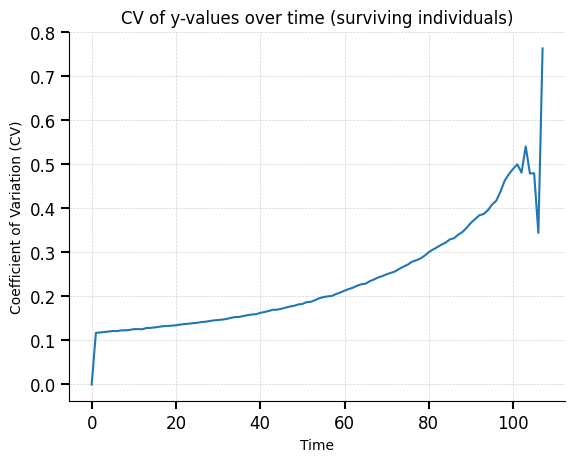

In [6]:
sim1.plot_CV()

<Axes: xlabel='Time', ylabel='Survival Probability'>

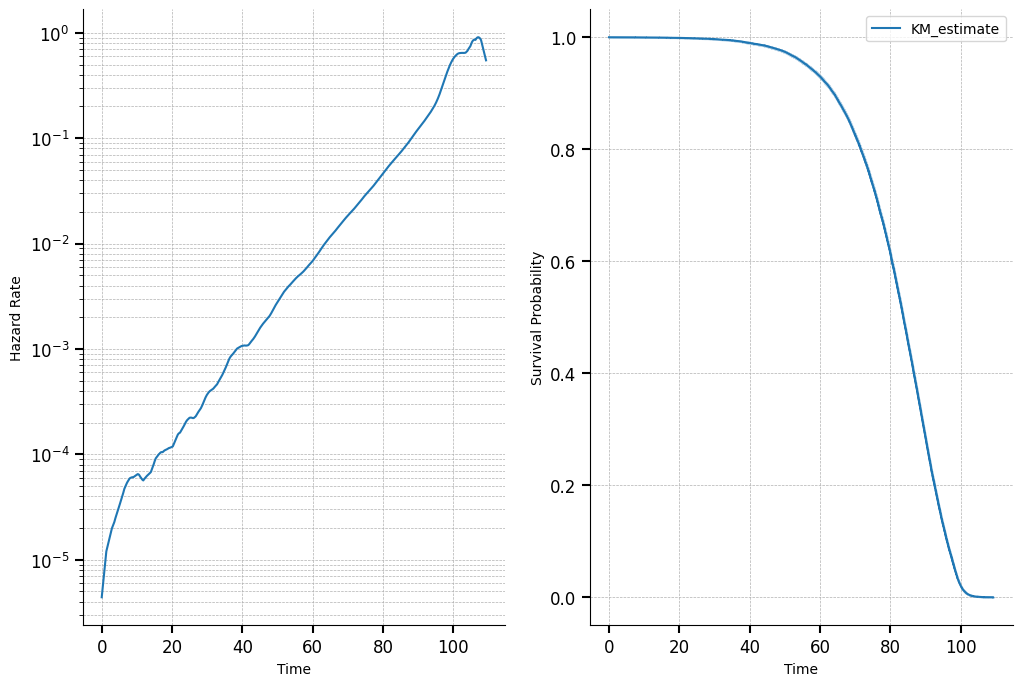

In [4]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,8))
sim1.plot_hazard(ax=ax1)
sim1.plot_survival(ax=ax2)


finished  0.3
finished  0.4
finished  0.5
finished  0.6
finished  0.7
finished  0.8
finished  0.9
finished  1.0
finished  1.1
finished  1.2
finished  1.3
finished  1.4
finished  1.5
finished  1.6
finished  1.7


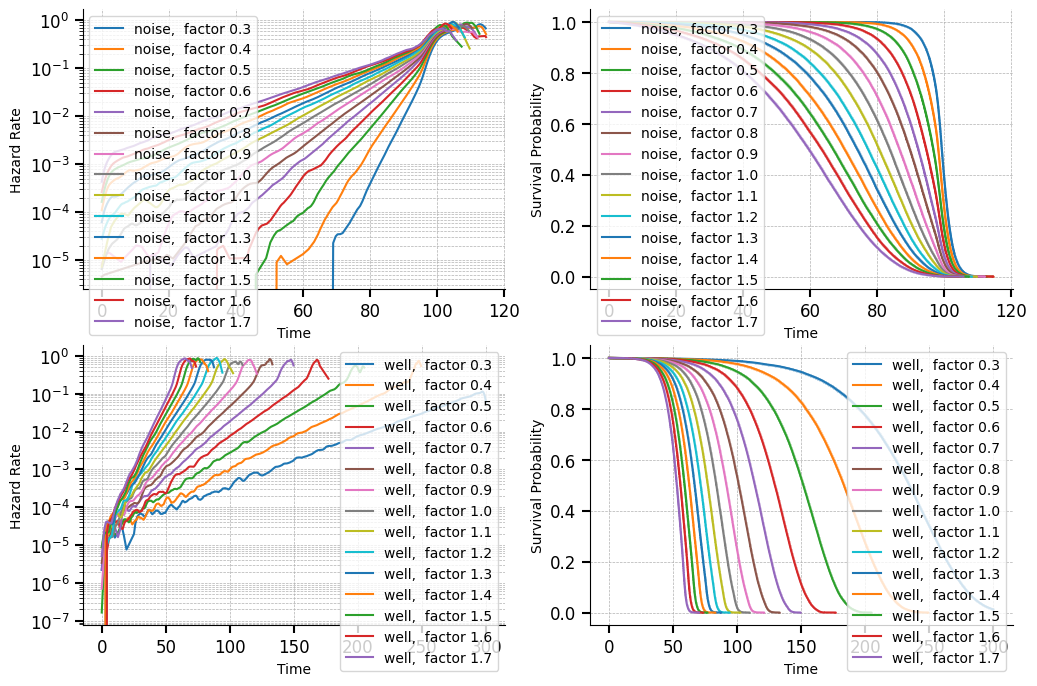

In [24]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12,8))
# Initialize dictionaries to store results
noise_results = {}
well_results = {}
factors = np.arange(0.3, 1.71, 0.1)
# round down factors to 1 decimal place
factors = np.round(factors, 1)
for factor in factors:
    delta_temp = delta * factor
    sim = DoubleWell(lamda, delta_temp, well=1, n=5000, y0=1.0, dt=1e-2, tmax=300, parallel=True, save_paths=False)
    sim.plot_hazard(ax=ax1, label=f'noise,  factor {factor}')
    sim.plot_survival(ax=ax2, label=f'noise,  factor {factor}')
    
    # Calculate and store median survival and steepness for noise variation
    noise_results[factor] = {
        'median_survival': sim.median_t,
        'steepness': sim.steepness
    }
        
    lamda_temp = lamda * factor
    sim = DoubleWell(lamda_temp, delta, well=1, n=5000, y0=1.0, dt=1e-2, tmax=300, parallel=True, save_paths=False)
    sim.plot_hazard(ax=ax3, label=f'well,  factor {factor}')
    sim.plot_survival(ax=ax4, label=f'well,  factor {factor}')
    
    # Calculate and store median survival and steepness for well variation
    well_results[factor] = {
        'median_survival': sim.median_t,
        'steepness': sim.steepness
    }
    
    print("finished ", factor)
    
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()

### steepness longevity

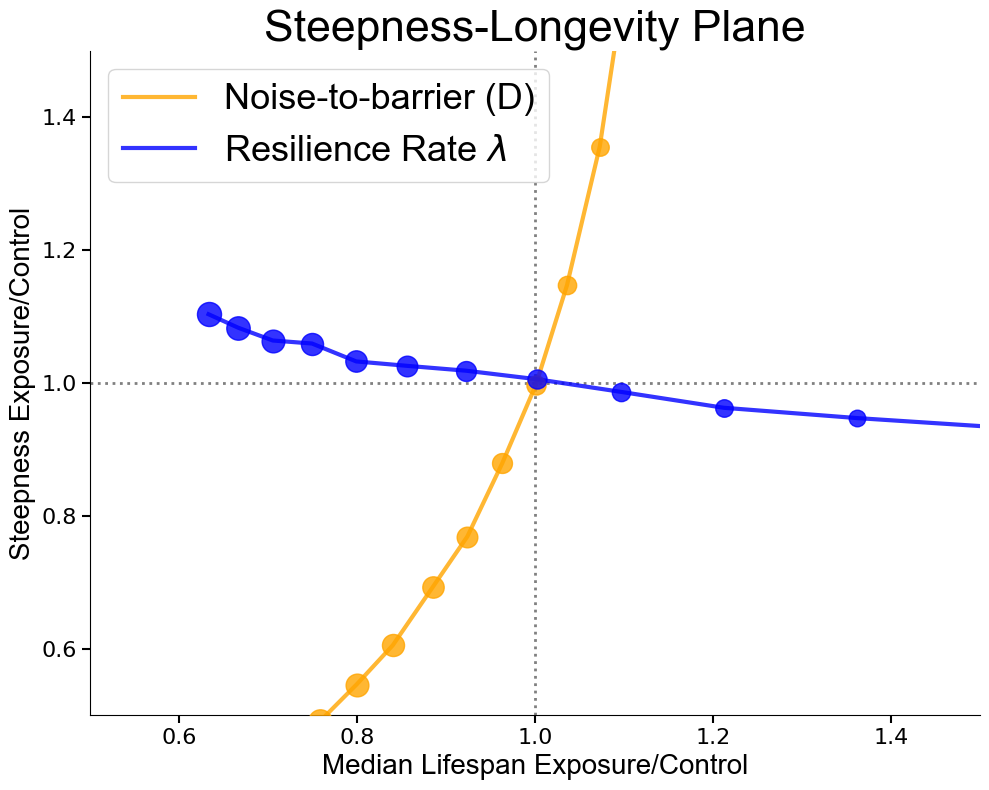

In [35]:
# Plot steepness vs longevity for both noise and well variations
fig, ax = plt.subplots(figsize=(10, 8))

# Extract factors and create normalized values for noise results
noise_factors = sorted(noise_results.keys())
noise_steepness_norm = [noise_results[f]['steepness'] / sim1.steepness for f in noise_factors]
noise_longevity_norm = [noise_results[f]['median_survival'] / sim1.median_t for f in noise_factors]

# Extract factors and create normalized values for well results
well_factors = sorted(well_results.keys())

well_steepness_norm = [well_results[f]['steepness'] / sim1.steepness for f in well_factors]
well_longevity_norm = [well_results[f]['median_survival'] / sim1.median_t for f in well_factors]

# Set up point sizes based on factor (larger for higher factor)
def scale_sizes(factors, min_size=80, max_size=300):
    factors = np.array(factors)
    if np.allclose(factors, factors[0]):
        return np.full_like(factors, (min_size + max_size) // 2)
    norm = (factors - factors.min()) / (factors.max() - factors.min())
    return min_size + norm * (max_size - min_size)

noise_sizes = scale_sizes(noise_factors)
well_sizes = scale_sizes(well_factors)

# Plot connecting lines
ax.plot(noise_longevity_norm, noise_steepness_norm, color='orange', linewidth=3, alpha=0.8, label='Noise variations')
ax.plot(well_longevity_norm, well_steepness_norm, color='blue', linewidth=3, alpha=0.8, label='Well variations')

# Plot noise results (points) - all circles, no individual factor legend
for i, factor in enumerate(noise_factors):
    ax.scatter(noise_longevity_norm[i], noise_steepness_norm[i], 
               color='orange', s=noise_sizes[i], alpha=0.8, marker='o',
               label=None, zorder=3)

# Plot well results (points) - all circles, no individual factor legend
for i, factor in enumerate(well_factors):
    ax.scatter(well_longevity_norm[i], well_steepness_norm[i], 
               color='blue', s=well_sizes[i], alpha=0.8, marker='o',
               label=None, zorder=3)

# (Removed baseline point and label)

# Set symmetric xlim and ylim
ax.set_xlim(0.5, 1.5)
ax.set_ylim(0.5, 1.5)

# Set labels and title with requested font sizes and Arial font
ax.set_xlabel('Median Lifespan Exposure/Control', fontsize=20, fontname='Arial')
ax.set_ylabel('Steepness Exposure/Control', fontsize=20, fontname='Arial')
ax.set_title('Steepness-Longevity Plane', fontname='Arial', fontsize=32)
ax.tick_params(axis='both', which='major', labelsize=16)

# Add grey dotted lines at x=1 and y=1
ax.axvline(x=1, color='grey', linestyle=':', linewidth=2, zorder=1)
ax.axhline(y=1, color='grey', linestyle=':', linewidth=2, zorder=1)

# Remove grid
ax.grid(False)

# Only show legend for the two lines, not the baseline
handles, labels = ax.get_legend_handles_labels()
from collections import OrderedDict
by_label = OrderedDict(zip(labels, handles))

# Map the actual plotted line labels to the desired legend labels
label_map = {
    'Noise variations': 'Noise-to-barrier (D)',
    'Well variations': r'Resilience Rate $\lambda$'
}

legend_handles = []
legend_labels = []
for orig_label, new_label in label_map.items():
    if orig_label in by_label:
        legend_handles.append(by_label[orig_label])
        legend_labels.append(new_label)

# Fix: Use a FontProperties object for the legend to ensure font size and family are respected
from matplotlib.font_manager import FontProperties
legend_font = FontProperties(family='Arial', size=26)
leg = ax.legend(legend_handles, legend_labels, prop=legend_font, loc='best', frameon=True)
# Explicitly set the font for all legend text (sometimes needed for notebook rendering)
for text in leg.get_texts():
    text.set_fontname('Arial')
    text.set_fontsize(26)

plt.tight_layout()
plt.show()


# Time dependence 3 (Weibully)

SM relation is maintained for different

To get semi-Gompertz, we assume $b(t) = b_0(1+\gamma t)$.

This yields the following dimensionless Langevin:

$$ \frac{dy}{d\tau} = 2y - 2y^3 (1+\lambda \tau)+ \sqrt{\delta} \eta(\tau) $$

If we interpet $y$ as damage or something, recall that $y_0 = 1$ and death is at $y=0$, so in that case "production" is $\text{production} = 2y^3 (1+\lambda \tau)$ and removal is $\text{removal} = 2y$

There are only two dimensionless parameters, $\lambda$ which is the change in the shape of the potential, and $\delta$ which is the relative strength of the noise.
This is the equation we simulate.

In [98]:
h0 = 1e-5
alpha = 0.09
# from analytical considerations
a0 = 1 # fundamental timescale in years

delta = 1 / np.log(np.sqrt(2)*a0/(np.pi*h0))
lamda = alpha / (1/delta - 1/2)



print('1/lambda = ', 1/lamda, 'delta = ', delta)

sim3 = DoubleWell(lamda=lamda, delta=delta, a0 = 3 , well=3, n=50000, y0=1.0, dt=1e-2, tmax=400, parallel=True, save_paths=True)

1/lambda =  113.49743521556448 delta =  0.0933291220921302


<Axes: xlabel='Time', ylabel='Hazard Rate'>

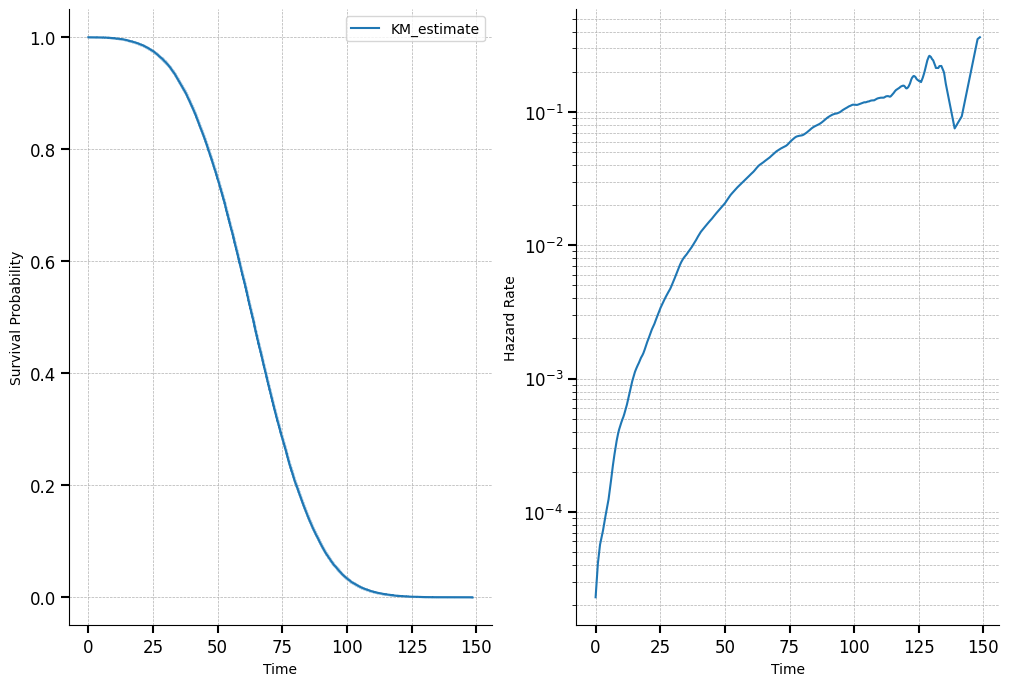

In [100]:
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12,8))
sim3.plot_survival(ax=ax1)
sim3.plot_hazard(ax=ax2)

finished  0.7
finished  0.8
finished  0.9
finished  1.0
finished  1.1
finished  1.2
finished  1.3


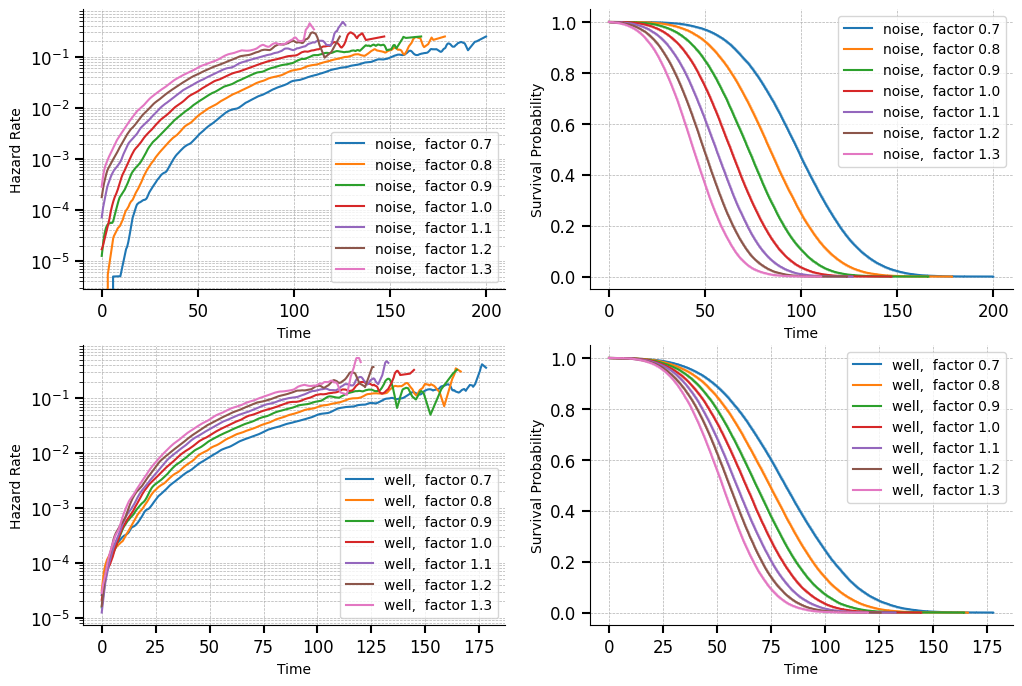

In [101]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12,8))
# Initialize dictionaries to store results
noise_results = {}
well_results = {}

for factor in [0.7, 0.8, 0.9, 1.0, 1.1, 1.2,1.3]:
    delta_temp = delta * factor
    sim = DoubleWell(lamda=lamda, delta=delta_temp, a0 = 3 , well=3, n=50000, y0=1.0, dt=1e-2, tmax=400, parallel=True, save_paths=True)
    sim.plot_hazard(ax=ax1, label=f'noise,  factor {factor}')
    sim.plot_survival(ax=ax2, label=f'noise,  factor {factor}')
    
    # Calculate and store median survival and steepness for noise variation
    noise_results[factor] = {
        'median_survival': sim.median_t,
        'steepness': sim.steepness
    }
        
    lamda_temp = lamda * factor
    sim = DoubleWell(lamda=lamda_temp, delta=delta, a0 = 3 , well=3, n=50000, y0=1.0, dt=1e-2, tmax=400, parallel=True, save_paths=True)
    sim.plot_hazard(ax=ax3, label=f'well,  factor {factor}')
    sim.plot_survival(ax=ax4, label=f'well,  factor {factor}')
    
    # Calculate and store median survival and steepness for well variation
    well_results[factor] = {
        'median_survival': sim.median_t,
        'steepness': sim.steepness
    }
    
    print("finished ", factor)
    
ax1.legend()
ax2.legend()
ax3.legend()
ax4.legend()